<a href="https://colab.research.google.com/github/Jingxian12/FastFood-LLM-reviews-analytics/blob/main/notebook/FastFood_Review_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **<div align = center > TITLE : Fast Food Review Analytics: End-to-End LLM Pipeline & Streamlit Dashboard**</div>

**Summary :**

**The objective**
- The main goal of this project is to use a **Large Language Model (LLM)** for **multi-label classification** to automatically find `customer problems in reviews`. Because a single review can mention multiple issues (like food quality and slow service), this classification helps the business quickly identify operational weaknesses and improve customer satisfaction through a **Streamlit dashboard**.


**Part A: ETL & Data Preprocessing**
- We clean the raw data by removing missing review texts and dropping irrelevant columns. We then standardize and format the data into a clean dataframe (normalize_df) so it is ready for the LLM.

**Part B: Text Analysis & LLM Evaluation Strategy**
- Before running the LLM on all reviews, we test its accuracy. We manually label a small subset of data to create a **"Ground Truth" benchmark**, then evaluate the LLM's performance using multi-label metrics like `F1-Score`, `Hamming Loss`, and `Subset Accuracy` to ensure its predictions are reliable.

**Part C: Large-Scale LLM Inference & Final Classification**
- We run the validated LLM across the entire `normalize_df` dataset to tag all customer complaints. Finally, we export the clean data into a final CSV file to power our **Streamlit dashboard**.

### **- Import Necessary Libraries**

In [ ]:
!pip install -q google-generativeai

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import json
import os
import sys
import ast

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **PART A : ETL & Data Preprocessing**

## **A) Data Loading**

I have collected review data for 3 brands **(McDonald's, KFC and Burger king)**. Each brand includes 5 locations, which are `Subang Jaya`, `Puchong`, `Sepang`, `Cyberjaya` and `Setapak`

The data was scraped using **Apify Website Google Map Reviewer Scrapers** (https://apify.com/compass/google-maps-reviews-scraper)

#### **Load Datasets**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/project/fnb_nlp/datasets/google_reviews_data.csv')
print(df.shape)

(7267, 8)


## **B) Data Inspection**

Before data cleaning phase, we need to check the quality of data first.

#### **- Initial Inspection**

In [ ]:
df.sample(5)

,title,address,city,stars,text,originalLanguage,textTranslated,translatedLanguage
4144,KFC Cyber Valley DT,"Lot No. PT 46622, HSD 33383, Cyber Valley Deng...",Sepang,2,Saya order 4 set untuk 2pcs rice combo tapi ha...,ms,I ordered 4 sets for 2pcs rice combo but only ...,en
3281,KFC Cyber Valley DT,"Lot No. PT 46622, HSD 33383, Cyber Valley Deng...",Sepang,1,"5 kali order drive thru sini, 4 kali cashier s...",id,"5 times I ordered drive thru here, 4 times the...",en
3631,McDonald's Subang Jaya DT,"1, Jalan SS 15/3a, Ss 15, 47500 Subang Jaya, S...",Subang Jaya,1,I had a very bad experience at this branch dur...,en,NaN,NaN
5694,Burger King Wangsa Maju,"No 2,Lot 28055 PT 8613, Jalan Wangsa Delima, P...",Wangsa Maju,3,Slow service. Gloomy environment. But its burg...,en,NaN,NaN
6234,KFC Jalan Genting Klang,"2, Jalan 2/50C, Off, Jalan Genting Kelang, Tam...",Kuala Lumpur,1,NaN,NaN,NaN,NaN


In [ ]:
df["text"].sample(10, random_state=42)

,text
1414,NaN
4610,NaN
2862,"Serius, ini dah berapa kali kena tunggu sejam ..."
4078,为什么我的white chocolate strawberry pie 是空的？里面没有任何东西！
3964,Ramai orang dan lambat.. better cari mcD cawan...
3542,"I bought from this mcd so many times,but the d..."
6011,"Staffs were very slow, took more than 10mins w..."
5239,บริการแย่ ส่งอาหารช้ามาก รอเป็นชั่วโมงยังไม่ได...
3815,Sistem baru yang sampah. Semua orang tunggu ma...
468,The barista did not wipe the milk vapour tube....


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   title               7267 non-null   object
 1   address             7267 non-null   object
 2   city                7267 non-null   object
 3   stars               7267 non-null   int64 
 4   text                5270 non-null   object
 5   originalLanguage    5275 non-null   object
 6   textTranslated      1353 non-null   object
 7   translatedLanguage  1356 non-null   object
dtypes: int64(1), object(7)
memory usage: 454.3+ KB


From here, we can see that column **"text"** have missing values

- Since our primary objective is to perform **multi-label text classification and category extraction** on informal, local **Rojak language reviews**, we must strictly preserve rows that contain valid text data.

- Any row missing a text review provides no value to our NLP pipeline, so these incomplete entries must be systematically removed before passing the data to the LLM.

#### **- Remove Missing Text**

In [ ]:
missing_text = df['text'].isna().sum()
print("Missing text in dataset is :", missing_text)

Missing text in dataset is : 1997


In [ ]:
# Drop Missing Values on 'text'
df = df.dropna(subset=['text'])

## **C) Data Cleaning**

In this stage, we clean and standardize the formatting across our columns. Raw data often suffers from inconsistencies like mismatched text capitalization, extra whitespaces, or categorical formats.


### **- Standardization each columns**

In [ ]:
clean_df = df.copy()

In [ ]:
display(clean_df.head(1))
print(clean_df.shape)

,title,address,city,stars,text,originalLanguage,textTranslated,translatedLanguage
0,McDonald's Cyberjaya DT,"Prima 5B, Prima Avenue 1, Jalan Teknorat 5, Cy...",Selangor,1,"Been their customer for quite long, extremely...",en,NaN,NaN


(5270, 8)


In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5270 entries, 0 to 7266
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   title               5270 non-null   object
 1   address             5270 non-null   object
 2   city                5270 non-null   object
 3   stars               5270 non-null   int64 
 4   text                5270 non-null   object
 5   originalLanguage    5270 non-null   object
 6   textTranslated      1353 non-null   object
 7   translatedLanguage  1354 non-null   object
dtypes: int64(1), object(7)
memory usage: 370.5+ KB


#### **- Title**

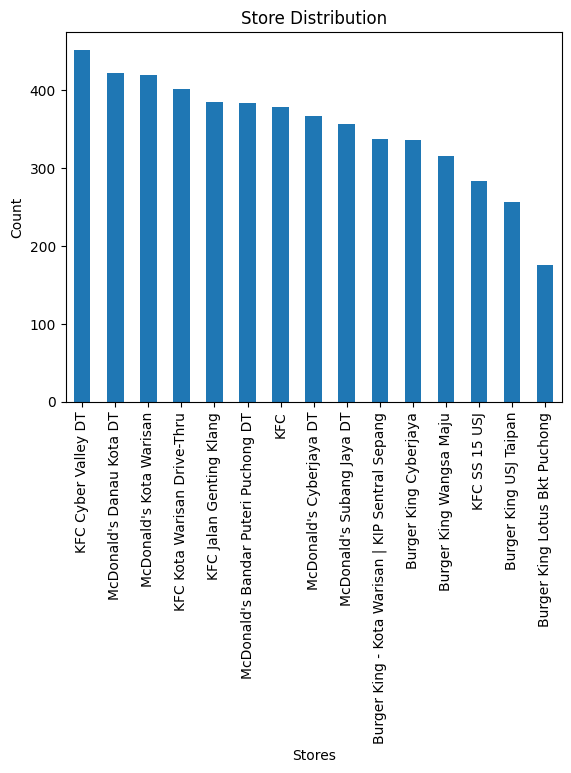

In [ ]:
# Before Standardization
clean_df["title"].value_counts().plot(kind="bar")

plt.title("Store Distribution")
plt.xlabel("Stores")
plt.ylabel("Count")
plt.show()

In [ ]:
clean_df['title'].value_counts()

,count
title,
KFC Cyber Valley DT,452
McDonald's Danau Kota DT,422
McDonald's Kota Warisan,420
KFC Kota Warisan Drive-Thru,402
KFC Jalan Genting Klang,385
McDonald's Bandar Puteri Puchong DT,384
KFC,378
McDonald's Cyberjaya DT,367
McDonald's Subang Jaya DT,357


The `title` column was not standardized and contained both brand and branch information. A rule-based parsing approach was applied to extract structured features for downstream analysis.

In [ ]:
# 1. Define filtering conditions (case = False : case-insensitive)
conditions = [
    clean_df["title"].str.contains("McDonald", case=False, na=False),
    clean_df["title"].str.contains("KFC", case=False, na=False),
    clean_df["title"].str.contains("Burger King", case=False, na=False),
]

# 2. Define corresponding standardized brand names
choices = ["McD", "KFC", "Burger King"]

# 3. Create a new column (fallback to original title if no match is found)
clean_df["brand"] = np.select(conditions, choices, default=clean_df["title"])

In [ ]:
clean_df['brand'].value_counts()

,count
brand,
McD,1950
KFC,1901
Burger King,1419


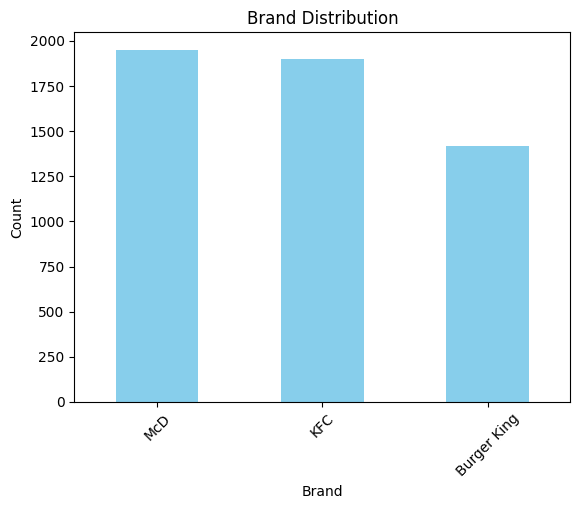

In [ ]:
# EDA for "brand"
clean_df['brand'].value_counts().plot(kind ="bar", color="skyblue")

plt.title("Brand Distribution")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Make title complete
kfc_puchong_mask = ((clean_df["title"].str.lower() == "kfc") & (clean_df["city"].str.lower() == "puchong") &
                    (clean_df["address"].str.contains("Puteri 7/13A", case=False, na=False)))
clean_df.loc[kfc_puchong_mask, "title"] = "KFC Bandar Puteri Puchong DT"


# Create Branch Name
clean_df["branch_name"] = (clean_df["title"]
    # 1. Strip out McDonald's, KFC, or Burger King all at once (case-insensitive)
    .str.replace(r"McDonald's|McDonalds|McD|KFC|Burger King", "", case=False, regex=True)
    # 2. Strip leftover symbols like dashes, spaces, or @ from edges
    .str.replace(r"^[\s\-_@]+|[\s\-_@]+$", "", regex=True)
    # 3. Clean up final trailing whitespaces
    .str.strip()
)

Since `address` for every branch is unique, so no need to standardize it.

#### **- City**

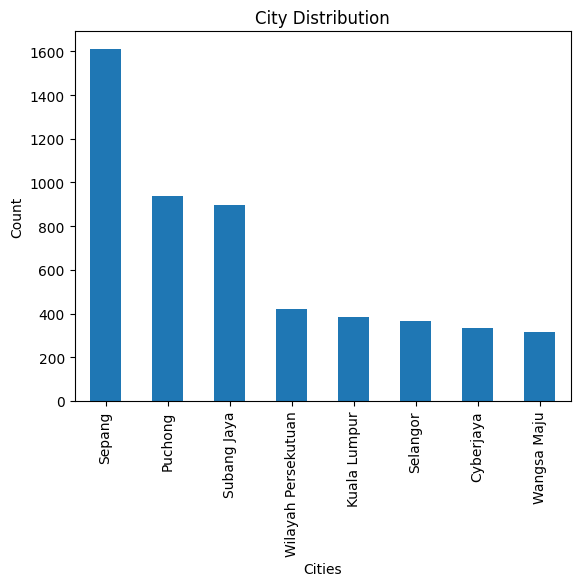

In [ ]:
# Before Standardization
clean_df['city'].value_counts().plot(kind ="bar")

plt.title("City Distribution")
plt.xlabel("Cities")
plt.ylabel("Count")
plt.show()

In [ ]:
# Show all unique combinations of title, city
unique_pairs = clean_df[["title","city"]].drop_duplicates()

# Sort the result by the 'city' column alphabetically
unique_pairs_sorted = unique_pairs.sort_values(by="city")

# Display the sorted dataframe
unique_pairs_sorted

,title,city
1040,Burger King Cyberjaya,Cyberjaya
2060,KFC Jalan Genting Klang,Kuala Lumpur
160,McDonald's Bandar Puteri Puchong DT,Puchong
1260,Burger King Lotus Bkt Puchong,Puchong
4147,KFC Bandar Puteri Puchong DT,Puchong
0,McDonald's Cyberjaya DT,Selangor
920,KFC Cyber Valley DT,Sepang
3047,KFC Kota Warisan Drive-Thru,Sepang
3147,McDonald's Kota Warisan,Sepang
3547,Burger King - Kota Warisan | KIP Sentral Sepang,Sepang


From graph and table , we can see that the city names distribution in the brand location data are inconsistent for several branches and require standardization.

In [ ]:
# 1. Define the explicit branch-to-city map
branch_city_map = {
    "KFC Jalan Genting Klang": "Setapak",
    "Burger King Wangsa Maju": "Setapak",
    "McDonald's Danau Kota DT": "Setapak",
    "McDonald's Cyberjaya DT": "Cyberjaya",
    "KFC Cyber Valley DT": "Cyberjaya"
}

# 2. Map the titles, and fill the unmapped branches with the original 'city' column
clean_df["city"] = clean_df["title"].map(branch_city_map).fillna(clean_df["city"])

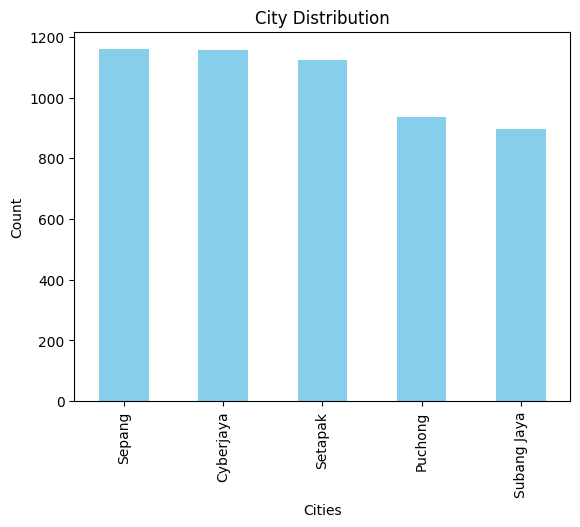

In [ ]:
# EDA for "city"
clean_df['city'].value_counts().plot(kind ="bar", color="skyblue")

plt.title("City Distribution")
plt.xlabel("Cities")
plt.ylabel("Count")
plt.show()

#### **- Stars**

In [ ]:
clean_df["stars"].value_counts()

,count
stars,
1,3363
2,850
3,601
4,280
5,176


In [ ]:
# Create a clean sentiment label based on stars
star_map = {5: "Positive", 4: "Positive", 3: "Neutral", 2: "Negative", 1: "Negative"}
clean_df["sentiment"] = clean_df["stars"].map(star_map)

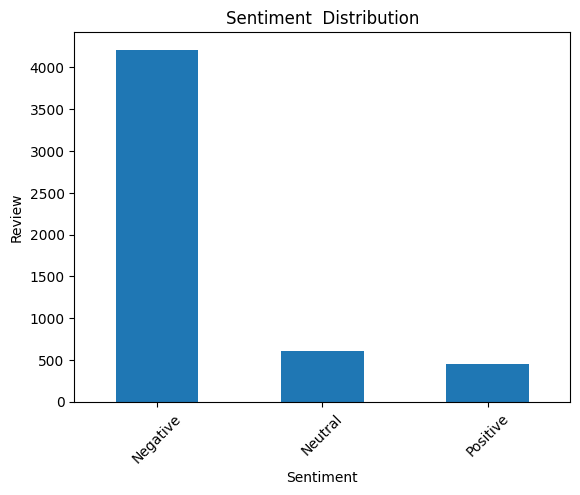

In [ ]:
clean_df["sentiment"].value_counts().plot(kind ="bar")

plt.title("Sentiment  Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Review")
plt.xticks(rotation=45)
plt.show()

Since the business needs to focus on finding problems, I'm keeping only the negative reviews and filtering out the neutral and postive reviews  as noise.

In [ ]:
clean_df = clean_df[clean_df["sentiment"] == "Negative"]

In [ ]:
clean_df.shape

(4213, 11)

In [ ]:
clean_df.head(1)

,title,address,city,stars,text,originalLanguage,textTranslated,translatedLanguage,brand,branch_name,sentiment
0,McDonald's Cyberjaya DT,"Prima 5B, Prima Avenue 1, Jalan Teknorat 5, Cy...",Cyberjaya,1,"Been their customer for quite long, extremely...",en,NaN,NaN,McD,Cyberjaya DT,Negative


In [ ]:
clean_df = clean_df.drop(columns=["title"])

In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4213 entries, 0 to 6460
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   address             4213 non-null   object
 1   city                4213 non-null   object
 2   stars               4213 non-null   int64 
 3   text                4213 non-null   object
 4   originalLanguage    4213 non-null   object
 5   textTranslated      1244 non-null   object
 6   translatedLanguage  1245 non-null   object
 7   brand               4213 non-null   object
 8   branch_name         4213 non-null   object
 9   sentiment           4213 non-null   object
dtypes: int64(1), object(9)
memory usage: 362.1+ KB


In [ ]:
# Specify the columns you care about at the front
front_columns = ["brand", "branch_name"]

# Automatically grab all remaining columns that are NOT in the front list
remaining_columns = [col for col in clean_df.columns if col not in front_columns]

# Combine them together to reorder
clean_df = clean_df[front_columns + remaining_columns]

In [ ]:
clean_df.head(1)

,brand,branch_name,address,city,stars,text,originalLanguage,textTranslated,translatedLanguage,sentiment
0,McD,Cyberjaya DT,"Prima 5B, Prima Avenue 1, Jalan Teknorat 5, Cy...",Cyberjaya,1,"Been their customer for quite long, extremely...",en,NaN,NaN,Negative


#### **- originalLanguage**

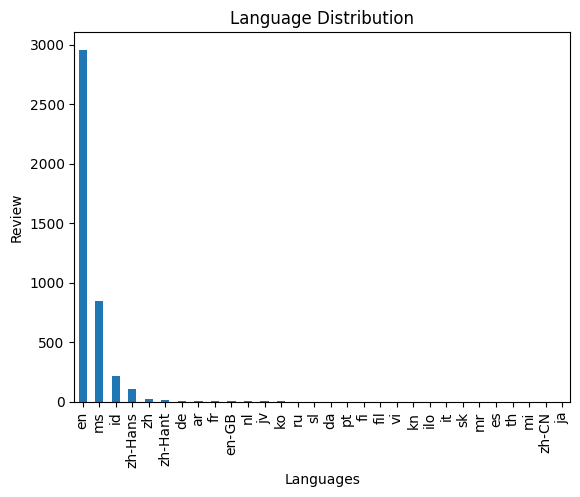

In [ ]:
# Before Standardization
clean_df["originalLanguage"].value_counts().plot(kind ="bar")

plt.title("Language Distribution")
plt.xlabel("Languages")
plt.ylabel("Review")
plt.show()

In [ ]:
clean_df["originalLanguage"].value_counts()

,count
originalLanguage,
en,2956
ms,847
id,216
zh-Hans,105
zh,26
zh-Hant,17
de,5
ar,5
fr,4


Since google translate might not be accurate, so i focus on manually checking the language that data below than 100 , and i notice that some of the review text is because of the malay short form (such as "blh je", "aq"), so need to normalize first before embeddings.

In [ ]:
# 1. Define the correction map for misclassified slang languages
language_correction_map = {
    # Slang misclassified as rare languages -> change back to Malay (ms)
    # Malay / Indonesian variants
    "fi": "ms", "fil": "ms","ilo": "ms","jv": "ms","kn": "ms", "mi": "ms", "mr": "ms",
    "id" : "ms",

    # Slang misclassified as rare languages -> change back to English (en)
    # English variants
    "da": "en", "pt": "en","sk": "en","en-GB" : "en", "en-US" : "en",

    # Slang misclassified as rare languages -> change back to Mandarin (zh)
    # Chinese variants (Simplified, Traditional, General, Taiwan)
    "zh-Hans":"zh", "zh-Hant":"zh", "zh-TW":"zh"
}

# 2. Apply the correction map using .replace()
# This will ONLY change the keys listed above, leaving 'en', 'ms', 'zh-Hans', etc., completely untouched!
clean_df["originalLanguage"] = clean_df["originalLanguage"].replace(language_correction_map)

In [ ]:
malaysia_languages = ["en", "ms", "zh"]

# Create a boolean mask: True for Local languages, False for Tourist languages
is_local = clean_df["originalLanguage"].isin(malaysia_languages)

# ---- Process 'clean_text' ----
# Logic: IF local language ➔ Use original text
# ELSE (Tourist) ➔ IF translation exists, use it; ELSE fall back to original text
tourist_text = np.where(clean_df["textTranslated"].notna(),
                                clean_df["textTranslated"],
                                clean_df["text"])

clean_df["clean_text"] = np.where(is_local, clean_df["text"], tourist_text)


# ---- Process 'clean_language' ----
# Logic: IF local language ➔ Use original language code
# ELSE (Tourist) ➔ IF translation exists, use it; ELSE fall back to original language code
tourist_language = np.where(clean_df["textTranslated"].notna(),
                                clean_df["translatedLanguage"],
                                clean_df["originalLanguage"])

clean_df["clean_language"] = np.where(is_local, clean_df["originalLanguage"], tourist_language)


In [ ]:
clean_df["clean_language"].value_counts()

,count
clean_language,
en,2990
ms,1072
zh,148
de,2
ar,1


In [ ]:
# Filter for NaN translations AND specific original languages
translate_empty = clean_df[
    clean_df["textTranslated"].isna() &
    clean_df["originalLanguage"].isin(["ar","de"])
]
translate_empty[['text','originalLanguage','clean_text','clean_language']]

,text,originalLanguage,clean_text,clean_language
453,The worst brach.,de,The worst brach.,de
5273,So bad,de,So bad,de
5281,Jamed,ar,Jamed,ar


From here, we can notice that original text "de" reviews are engligh , so we make them as "en" , but for "ar", since it is noise , so we can remove it.

In [ ]:
# 1. Define the correction map for misclassified slang languages
language_correction_map = {"de" : "en"}

# 2. Apply the correction map using .replace()
clean_df["clean_language"] = clean_df["clean_language"].replace(language_correction_map)

In [ ]:
# drop index 5281
clean_df.drop(5281, inplace=True)

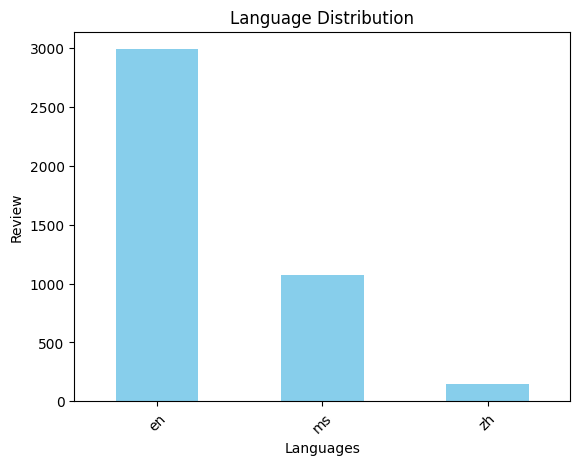

In [ ]:
# EDA for "language"
clean_df["clean_language"].value_counts().plot(kind ="bar", color = "skyblue")

plt.title("Language Distribution")
plt.xlabel("Languages")
plt.ylabel("Review")
plt.xticks(rotation = 45)
plt.show()

#### **- Remove Columns**

In [ ]:
clean_df.isna().sum()

,0
brand,0
branch_name,0
address,0
city,0
stars,0
text,0
originalLanguage,0
textTranslated,2968
translatedLanguage,2967
sentiment,0


In [ ]:
columns_to_drop = ["text", "originalLanguage","textTranslated", "translatedLanguage"]
clean_df = clean_df.drop(columns=columns_to_drop)

# **PART B : Text Analysis & LLM Evaluation Strategy**

## **D) Exploratory Text Analysis**

In [ ]:
normalize_df = clean_df.copy()

In [ ]:
normalize_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4212 entries, 0 to 6460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   brand           4212 non-null   object
 1   branch_name     4212 non-null   object
 2   address         4212 non-null   object
 3   city            4212 non-null   object
 4   stars           4212 non-null   int64 
 5   sentiment       4212 non-null   object
 6   clean_text      4212 non-null   object
 7   clean_language  4212 non-null   object
dtypes: int64(1), object(7)
memory usage: 296.2+ KB


In [ ]:
normalize_df.shape

(4212, 8)

#### **- Review Text Quality**

In [ ]:
def calculate_review_length(row):
    text = str(row["clean_text"])
    lang = row["clean_language"]

    if lang == "zh":
        # Remove whitespaces and count every Chinese character
        return len("".join(text.split()))
    else:
        # Standard word count via spaces for English/Malay
        return len(text.split())

# Apply the logic row-by-row across your DataFrame
normalize_df["review_length"] = normalize_df.apply(calculate_review_length, axis=1)

# Check the new descriptive statistics matrix
print(normalize_df["review_length"].describe())

count    4212.000000
mean       34.021605
std        38.817419
min         1.000000
25%        10.000000
50%        23.000000
75%        43.000000
max       483.000000
Name: review_length, dtype: float64


From descriptive statistics, we can reveal that this dataset have 75% of the customer reviews are concise, containing fewer than 43 words.

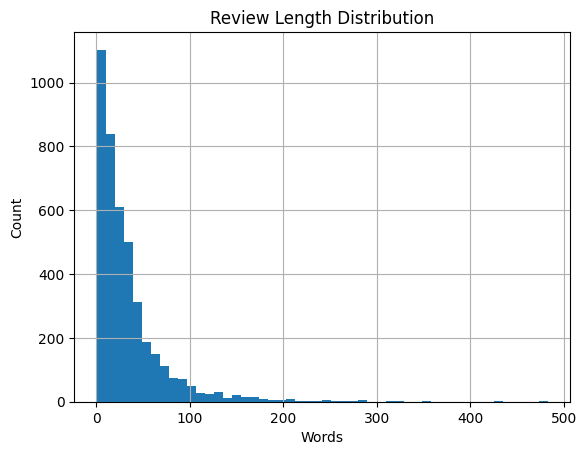

In [ ]:
normalize_df["review_length"].hist(bins=50)

plt.title("Review Length Distribution")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

In [ ]:
normalize_df = normalize_df.reset_index(drop=True)
normalize_df["review_id"] = normalize_df.index

## **E) Ground Truth Data**

Ground truth data is a human-verified dataset that serves as the absolute **"source of truth"** to test and measure the accuracy of our LLM's classification metrics.

### **- Create Ground Truth Data**

In [ ]:
# Perform length-based stratified sampling to build a representative evaluation dataset
short_review = normalize_df[(normalize_df['review_length'] >= 5) & (normalize_df['review_length'] <= 20)].sample(n=20, random_state=42)
normal_review = normalize_df[(normalize_df['review_length'] >= 23) & (normalize_df['review_length'] <= 50)].sample(n=100, random_state=42)
long_review = normalize_df[normalize_df['review_length'] > 50].sample(n=30, random_state=42)

# Combine the segmented samples into a single dataset
ground_truth_data = pd.concat([short_review, normal_review, long_review])

# Shuffle the combined dataset to mix different lengths for a better manual labeling experience
ground_truth_data = ground_truth_data.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
ground_truth_data.head(1)

,brand,branch_name,address,city,stars,sentiment,clean_text,clean_language,review_length,review_id
0,KFC,SS 15 USJ,"17, Jln SS 15/4G, Ss 15, 47500 Subang Jaya, Se...",Subang Jaya,1,Negative,I have ordered from this branch on more than o...,en,44,3323


In [ ]:
ground_truth_data = ground_truth_data[["clean_text","review_length","review_id"]]

In [ ]:
ground_truth_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_text     150 non-null    object
 1   review_length  150 non-null    int64 
 2   review_id      150 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ KB


In [ ]:
# # Export to Excel for manual Ground Truth annotation
# ground_truth_data.to_excel("/content/drive/MyDrive/project/fnb_nlp/datasets/ground_truth_data2.xlsx", index=False)
# print(f"Successfully generated dataset! Total samples: {len(ground_truth_data)}")

### **- Ground Truth Data (Human Annotate)**

I manually labeled a subset of reviews to create a ground truth dataset, which will be used to test the LLM's classification accuracy before running it on the full dataset.

In [ ]:
ground_truth_manual_label = pd.read_excel("/content/drive/MyDrive/project/fnb_nlp/datasets/ground_truth_data.xlsx")

In [ ]:
ground_truth_manual_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   clean_text                      150 non-null    object
 1   review_length                   150 non-null    int64 
 2   review_id                       150 non-null    int64 
 3   food_quality_detected           150 non-null    int64 
 4   order_accuracy_detected         150 non-null    int64 
 5   staff_professionalism_detected  150 non-null    int64 
 6   speed_of_service_detected       150 non-null    int64 
 7   hygiene_cleanliness_detected    150 non-null    int64 
 8   facility_equipment_detected     150 non-null    int64 
 9   product_availability_detected   150 non-null    int64 
 10  no_specific_complaint_detected  150 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 13.0+ KB


In [ ]:
ground_truth_manual_label.head(1)

,clean_text,review_length,review_id,food_quality_detected,order_accuracy_detected,staff_professionalism_detected,speed_of_service_detected,hygiene_cleanliness_detected,facility_equipment_detected,product_availability_detected,no_specific_complaint_detected
0,I have ordered from this branch on more than o...,44,3323,1,1,0,0,0,0,0,0


### **- Ground Truth Data (LLM Annotate)**

In [ ]:
import sys
# Add custom project directory to Python's module search path
sys.path.append('/content/drive/MyDrive/project/fnb_nlp/')

Append Google Drive folder to sys.path so files inside 'fnb_nlp' can be imported directly

In [ ]:
# Import module function and the Colab secrets manager
from llm_nlp import analyze_review_LLM
from google.colab import userdata
import pandas as pd


# Fetch API Key
API_KEY = userdata.get('nlp_api')
csv_path = "/content/drive/MyDrive/project/fnb_nlp/datasets/ground_truth_llm.csv"

# # tqdm will show a real-time progress bar. (Try with ground truth data first)
# df_result = analyze_review_LLM(
#     df= ground_truth_data,
#     text_column="clean_text",
#     api_key=API_KEY,
#     batch_size=50,
#     output_csv_path = csv_path,
#     verbose=True
# )

The annotation of label saved to Google Drive. We need to upload into Google Colab

In [ ]:
ground_truth_llm = pd.read_csv('/content/drive/MyDrive/project/fnb_nlp/datasets/ground_truth_llm.csv')

In [ ]:
ground_truth_llm[[
    "clean_text",
    "food_quality",
    "order_accuracy",
    "staff_professionalism",
    "speed_of_service",
    "hygiene_cleanliness",
    "facility_equipment",
    "product_availability",
    "no_specific_complaint",
    "is_api_fail"
]].head()

,clean_text,food_quality,order_accuracy,staff_professionalism,speed_of_service,hygiene_cleanliness,facility_equipment,product_availability,no_specific_complaint,is_api_fail
0,I have ordered from this branch on more than o...,"{'detected': 1, 'issues': ['hard bread', 'thin...","{'detected': 1, 'issues': ['missing items']}","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}",{'detected': 0},False
1,"Worst toilet. Ooh...no wonder, there's people ...","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}","{'detected': 1, 'issues': ['worst toilet']}","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}",{'detected': 0},False
2,The staff are very slow. The staff taking our ...,"{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}","{'detected': 1, 'issues': ['staff not cut out ...","{'detected': 1, 'issues': ['slow staff', 'staf...","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}",{'detected': 0},False
3,I’m As A Customer really fed up with this Kota...,"{'detected': 1, 'issues': ['Milo ais taste not...","{'detected': 0, 'issues': []}","{'detected': 1, 'issues': ['prepared food not ...","{'detected': 1, 'issues': ['too late service',...","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}",{'detected': 0},False
4,"order from food panda at 10:26 am , mash potat...","{'detected': 0, 'issues': []}","{'detected': 1, 'issues': ['missing spoon for ...","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}","{'detected': 1, 'issues': ['mash potato out of...",{'detected': 0},False


When saving the LLM's annotations to a CSV file, Python converts our list formatting into a plain string, so we must use the ast library to safely parse that string back into an actual list when reloading the data

In [ ]:
import ast
# Helper function to safely parse string to dict and convert 'detected' to 0 or 1
def safe_convert_detected(x):
    # If the data is string format (e.g. from CSV), parse it to a real dictionary
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return 0

    if isinstance(x, dict):
        val = x.get("detected")
        if val in [1, '1', True, 'True']:
            return 1
        elif val in [0, '0', False, 'False']:
            return 0
    return 0  # Default fallback if key missing or row analysis failed

# Helper function to safely parse string to dict and extract 'issues' list
def safe_extract_issues(x):
    # If the data is string format, parse it to a real dictionary
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return ""

    if isinstance(x, dict):
        issues_list = x.get("issues", [])
        if isinstance(issues_list, list):
            return ", ".join(str(i) for i in issues_list)
    return ""

In [ ]:
# 1. Define all evaluation categories that contain both 'detected' and 'issues'
categories = [
    "food_quality", "order_accuracy", "staff_professionalism",
    "speed_of_service", "hygiene_cleanliness",
    "facility_equipment", "product_availability"
]

# 2. Loop through each complex dictionary column to flatten it
for cat in categories:
    # Check if the column exists in the DataFrame to prevent errors
    if cat in ground_truth_llm.columns:

        # Extract the 'detected' flag and guarantee it returns exactly 0 or 1
        ground_truth_llm[f"{cat}_detected"] = ground_truth_llm[cat].apply(safe_convert_detected)

        # Extract the 'issues' array and join elements into a clean comma-separated string
        ground_truth_llm[f"{cat}_issues"] = ground_truth_llm[cat].apply(safe_extract_issues)

        # Drop the original nested dictionary column to keep the DataFrame clean
        ground_truth_llm.drop(columns=[cat], inplace=True)

# 3. Handle 'no_specific_complaint' separately (since it only has 'detected' and no 'issues' array)
if "no_specific_complaint" in ground_truth_llm.columns:

    # Extract the 'detected' flag for the overall complaint indicator
    ground_truth_llm["no_specific_complaint_detected"] = ground_truth_llm["no_specific_complaint"].apply(safe_convert_detected)

    # Drop the original nested column
    ground_truth_llm.drop(columns=["no_specific_complaint"], inplace=True)

In [ ]:
ground_truth_llm.head(1)

,clean_text,review_length,review_id,review_index,is_api_fail,food_quality_detected,food_quality_issues,order_accuracy_detected,order_accuracy_issues,staff_professionalism_detected,staff_professionalism_issues,speed_of_service_detected,speed_of_service_issues,hygiene_cleanliness_detected,hygiene_cleanliness_issues,facility_equipment_detected,facility_equipment_issues,product_availability_detected,product_availability_issues,no_specific_complaint_detected
0,I have ordered from this branch on more than o...,44,3323,1,False,1,"hard bread, thin and hard chicken patty",1,missing items,0,,0,,0,,0,,0,,0


### **- LLM Multi-Label Evaluation & Validation Metrics**

In [ ]:
from sklearn.metrics import classification_report, hamming_loss, accuracy_score

# Align both datasets precisely using 'review_id'
merged_eval = pd.merge(
    ground_truth_manual_label,
    ground_truth_llm,
    on='review_id',
    suffixes=('_true', '_pred')
)

# Define the 8 aligned core target label columns
target_tags = [
    'food_quality_detected',	'order_accuracy_detected',
    'staff_professionalism_detected',	'speed_of_service_detected',
    'hygiene_cleanliness_detected',	'facility_equipment_detected',
    'product_availability_detected','no_specific_complaint_detected']

# Extract matrices and format them into binary integers (0 and 1)
y_true = merged_eval[[col + '_true' for col in target_tags]].fillna(0).astype(int)
y_pred = merged_eval[[col + '_pred' for col in target_tags]].fillna(0).astype(int)

# Rename columns back to original tags for readable report alignment
y_true.columns = target_tags
y_pred.columns = target_tags

#### **Multi-Label Metrics**

Because a single review can contain multiple complaints simultaneously, we look at two specialized global metrics:

- **Subset Accuracy (Exact Match Ratio):** This is a strict metric that measures the `percentage of rows` where the LLM got every single label perfectly correct. If a review has 8 potential categories and the model misses just one, the entire row is counted as incorrect.

- **Hamming Loss:** This is a detailed metric that measures the fraction of individual label mistakes across the entire dataset. It scores the model on every single yes/no decision it makes. `The closer this score is to 0, the fewer mistakes the model is making overall`.

In [ ]:
# 4. Print global and per-category classification report (Precision, Recall, F1-score)
print("=================== Core Evaluation Report ===================")
print(classification_report(y_true, y_pred, target_names=target_tags, zero_division=0))

# 5. Print multi-label core loss metrics and subset accuracy
print("=================== Comprehensive Metrics ===================")
print(f"Hamming Loss: {hamming_loss(y_true, y_pred):.4f} (The closer to 0, the better)")
print(f"Subset Accuracy (Exact Match Ratio): {accuracy_score(y_true, y_pred):.4f} (Proportion of rows where all 8 categories match perfectly)")

=================== Core Evaluation Report ===================
                                precision    recall  f1-score   support

         food_quality_detected       1.00      1.00      1.00        40
       order_accuracy_detected       0.95      1.00      0.97        35
staff_professionalism_detected       0.94      0.89      0.92        74
     speed_of_service_detected       0.97      0.98      0.98        66
  hygiene_cleanliness_detected       0.93      1.00      0.97        14
   facility_equipment_detected       0.81      1.00      0.89        17
 product_availability_detected       0.67      1.00      0.80        10
no_specific_complaint_detected       1.00      0.83      0.91         6

                     micro avg       0.93      0.96      0.95       262
                     macro avg       0.91      0.96      0.93       262
                  weighted avg       0.94      0.96      0.95       262
                   samples avg       0.95      0.97      0.95       262

### 📊 Performance Evaluation Summary

- The evaluation shows that our LLM classifier is highly accurate, achieving an overall **F1-Score of 0.95**. It performs best on common complaints like `food_quality` and `speed_of_service`, though it occasionally over-identifies rare issues like `product_availability`.

- With a very low **Hamming Loss (0.0233)** and a high **Subset Accuracy (86%)**, the model successfully tags the exact combination of all 8 complaint categories perfectly for the vast majority of reviews, making it highly reliable for our final dashboard.

# **PART C : Large-Scale LLM Inference & Final Classification**

## **F) Batch LLM Annotation on Full Dataset**

In [ ]:
normalize_df.head(1)

,brand,branch_name,address,city,stars,sentiment,clean_text,clean_language,review_length,review_id
0,McD,Cyberjaya DT,"Prima 5B, Prima Avenue 1, Jalan Teknorat 5, Cy...",Cyberjaya,1,Negative,"Been their customer for quite long, extremely...",en,158,0


The entire `normalize_df` dataframe will now be used as the input dataset for batch LLM annotation."

In [ ]:
# Import module function and the Colab secrets manager
from llm_nlp import analyze_review_LLM
from google.colab import userdata

# Fetch API Key
API_KEY = userdata.get('nlp_api')
csv_path = "/content/drive/MyDrive/project/fnb_nlp/datasets/llm_df.csv"

# tqdm will show a real-time progress bar. (Try with ground truth data first)
# df_result = analyze_review_LLM(
#     df= normalize_df,
#     text_column="clean_text",
#     api_key=API_KEY,
#     batch_size=50,
#     output_csv_path = csv_path,
#     verbose=True
# )

✨ No existing backup found. Created new CSV tracker at: /content/drive/MyDrive/project/fnb_nlp/datasets/final_df_llm.csv


LLM Processing: 100%|██████████| 85/85 [1:52:27<00:00, 79.38s/it]


Execution finished completely! All metrics are safely mirrored at: /content/drive/MyDrive/project/fnb_nlp/datasets/final_df_llm.csv


In [ ]:
llm_df = pd.read_csv('/content/drive/MyDrive/project/fnb_nlp/datasets/llm_df.csv', on_bad_lines='skip')

In [ ]:
llm_df.head(1)

,brand,branch_name,address,city,stars,sentiment,clean_text,clean_language,review_length,review_id,review_index,food_quality,order_accuracy,staff_professionalism,speed_of_service,hygiene_cleanliness,facility_equipment,product_availability,no_specific_complaint,is_api_fail
0,McD,Cyberjaya DT,"Prima 5B, Prima Avenue 1, Jalan Teknorat 5, Cy...",Cyberjaya,1,Negative,"Been their customer for quite long, extremely...",en,158,0,1,"{'detected': 1, 'issues': ['burger condition']}","{'detected': 1, 'issues': ['no single sachet o...","{'detected': 1, 'issues': [""staff said 'biasa ...","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}","{'detected': 0, 'issues': []}",{'detected': 0},False


In [ ]:
llm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4162 entries, 0 to 4161
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   brand                  4162 non-null   object
 1   branch_name            4162 non-null   object
 2   address                4162 non-null   object
 3   city                   4162 non-null   object
 4   stars                  4162 non-null   int64 
 5   sentiment              4162 non-null   object
 6   clean_text             4162 non-null   object
 7   clean_language         4162 non-null   object
 8   review_length          4162 non-null   int64 
 9   review_id              4162 non-null   int64 
 10  review_index           4162 non-null   int64 
 11  food_quality           4162 non-null   object
 12  order_accuracy         4162 non-null   object
 13  staff_professionalism  4162 non-null   object
 14  speed_of_service       4162 non-null   object
 15  hygiene_cleanliness  

## **G) Exporting Final Processed Data for Streamlit Dashboard**

In [ ]:
# Helper function to safely parse string to dict and convert 'detected' to 0 or 1
def safe_convert_detected(x):
    # If the data is string format (e.g. from CSV), parse it to a real dictionary
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return 0

    if isinstance(x, dict):
        val = x.get("detected")
        if val in [1, '1', True, 'True']:
            return 1
        elif val in [0, '0', False, 'False']:
            return 0
    return 0  # Default fallback if key missing or row analysis failed

# Helper function to safely parse string to dict and extract 'issues' list
def safe_extract_issues(x):
    # If the data is string format, parse it to a real dictionary
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return ""

    if isinstance(x, dict):
        issues_list = x.get("issues", [])
        if isinstance(issues_list, list):
            return ", ".join(str(i) for i in issues_list)
    return ""

In [ ]:
import ast

# 1. Define all evaluation categories that contain both 'detected' and 'issues'
categories = [
    "food_quality", "order_accuracy", "staff_professionalism",
    "speed_of_service", "hygiene_cleanliness",
    "facility_equipment", "product_availability"
]

# 2. Loop through each complex dictionary column to flatten it
for cat in categories:
    # Check if the column exists in the DataFrame to prevent errors
    if cat in llm_df.columns:

        # Extract the 'detected' flag and guarantee it returns exactly 0 or 1
        llm_df[f"{cat}_detected"] = llm_df[cat].apply(safe_convert_detected)

        # Extract the 'issues' array and join elements into a clean comma-separated string
        llm_df[f"{cat}_issues"] = llm_df[cat].apply(safe_extract_issues)

        # Drop the original nested dictionary column to keep the DataFrame clean
        llm_df.drop(columns=[cat], inplace=True)

# 3. Handle 'no_specific_complaint' separately (since it only has 'detected' and no 'issues' array)
if "no_specific_complaint" in llm_df.columns:

    # Extract the 'detected' flag for the overall complaint indicator
    llm_df["no_specific_complaint_detected"] = llm_df["no_specific_complaint"].apply(safe_convert_detected)

    # Drop the original nested column
    llm_df.drop(columns=["no_specific_complaint"], inplace=True)

In [ ]:
llm_df.head(1)

,brand,branch_name,address,city,stars,sentiment,clean_text,clean_language,review_length,review_id,...,staff_professionalism_issues,speed_of_service_detected,speed_of_service_issues,hygiene_cleanliness_detected,hygiene_cleanliness_issues,facility_equipment_detected,facility_equipment_issues,product_availability_detected,product_availability_issues,no_specific_complaint_detected
0,McD,Cyberjaya DT,"Prima 5B, Prima Avenue 1, Jalan Teknorat 5, Cy...",Cyberjaya,1,Negative,"Been their customer for quite long, extremely...",en,158,0,...,"staff said 'biasa la bang, shift mlm mmng sorn...",0,,0,,0,,0,,0


In [ ]:
llm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4162 entries, 0 to 4161
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   brand                           4162 non-null   object
 1   branch_name                     4162 non-null   object
 2   address                         4162 non-null   object
 3   city                            4162 non-null   object
 4   stars                           4162 non-null   int64 
 5   sentiment                       4162 non-null   object
 6   clean_text                      4162 non-null   object
 7   clean_language                  4162 non-null   object
 8   review_length                   4162 non-null   int64 
 9   review_id                       4162 non-null   int64 
 10  review_index                    4162 non-null   int64 
 11  is_api_fail                     4162 non-null   bool  
 12  food_quality_detected           4162 non-null   

In [ ]:
llm_df.drop(columns=["stars","sentiment","clean_language","review_length","review_index","is_api_fail"], inplace=True)

In [ ]:
# llm_df.to_csv('/content/drive/MyDrive/project/fnb_nlp/datasets/final_df_llm.csv',encoding ="utf-8-sig", index=False)